In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mao_a_ic50.csv to mao_a_ic50.csv
Saving mao_b_ic50.csv to mao_b_ic50.csv
Saving AChE_Bioactivity_data_2.csv to AChE_Bioactivity_data_2.csv


In [ ]:
!pip install pandas matplotlib seaborn rdkit scikit-learn tensorflow datasets scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 18.8 MB/s eta 0:00:00


In [ ]:
!pip install transformers

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit import DataStructs
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import warnings
warnings.filterwarnings('ignore')


maob_df = pd.read_csv("mao_b_ic50.csv")
maoa_df = pd.read_csv("mao_a_ic50.csv")
ache_df = pd.read_csv("AChE_Bioactivity_data_2.csv")


maob_df = maob_df.rename(columns={'smiles': 'canonical_smiles', 'ic50': 'standard_value'})
maob_df['standard_value'] *= 1000
maob_df['target'] = 0

maoa_df = maoa_df.rename(columns={'smiles': 'canonical_smiles', 'ic50': 'standard_value'})
maoa_df['standard_value'] *= 1000
maoa_df['target'] = 1

ache_df['target'] = 2


df = pd.concat([maob_df, maoa_df, ache_df], ignore_index=True)
df = df.dropna(subset=['canonical_smiles', 'standard_value'])
df = df[(df['standard_value'] > 0) & (df['standard_value'] < 1_000_000)]


df = df.drop_duplicates(subset=['canonical_smiles'])
df['log_ic50'] = np.log10(df['standard_value'])
q1, q3 = df['log_ic50'].quantile([0.05, 0.95])
df = df[(df['log_ic50'] >= q1) & (df['log_ic50'] <= q3)]


def generate_enhanced_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(2048 + 50 + 3)


    generator2 = GetMorganGenerator(radius=2, fpSize=1024)
    generator3 = GetMorganGenerator(radius=3, fpSize=1024)

    fp2 = generator2.GetFingerprint(mol)
    fp3 = generator3.GetFingerprint(mol)


    arr2 = np.zeros(1024, dtype=int)
    arr3 = np.zeros(1024, dtype=int)
    DataStructs.ConvertToNumpyArray(fp2, arr2)
    DataStructs.ConvertToNumpyArray(fp3, arr3)


    try:
        descriptors = [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.NumAromaticRings(mol),
            Descriptors.NumSaturatedRings(mol),
            Descriptors.NumAliphaticRings(mol),
            Descriptors.RingCount(mol),
            Descriptors.HeavyAtomCount(mol),
            Descriptors.NumHeteroatoms(mol),
            Descriptors.BertzCT(mol),
            Chem.rdMolDescriptors.CalcNumSpiroAtoms(mol),
            Chem.rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
            len(Chem.GetMolFrags(mol)),  # Number of fragments
            Descriptors.MaxAbsEStateIndex(mol),
            Descriptors.MaxEStateIndex(mol),
            Descriptors.MinAbsEStateIndex(mol),
            Descriptors.MinEStateIndex(mol),
            Descriptors.qed(mol),
            Chem.rdMolDescriptors.CalcNumAromaticCarbocycles(mol),
            Chem.rdMolDescriptors.CalcNumAromaticHeterocycles(mol),
            Chem.rdMolDescriptors.CalcNumSaturatedCarbocycles(mol),
            Chem.rdMolDescriptors.CalcNumSaturatedHeterocycles(mol),
            Chem.rdMolDescriptors.CalcNumAliphaticCarbocycles(mol),
            Chem.rdMolDescriptors.CalcNumAliphaticHeterocycles(mol),
            Descriptors.SlogP_VSA1(mol),
            Descriptors.SlogP_VSA2(mol),
            Descriptors.SMR_VSA1(mol),
            Descriptors.SMR_VSA2(mol),
            Descriptors.PEOE_VSA1(mol),
            Descriptors.PEOE_VSA2(mol),
            Descriptors.VSA_EState1(mol),
            Descriptors.VSA_EState2(mol),
            len([x for x in mol.GetAtoms() if x.GetHybridization() == Chem.HybridizationType.SP3]),
            len([x for x in mol.GetAtoms() if x.GetHybridization() == Chem.HybridizationType.SP2]),
            len([x for x in mol.GetAtoms() if x.GetHybridization() == Chem.HybridizationType.SP]),
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 6]),  # Carbon count
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 7]),  # Nitrogen count
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 8]),  # Oxygen count
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 16]), # Sulfur count
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 9]),  # Fluorine count
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 17]), # Chlorine count
            len([x for x in mol.GetAtoms() if x.GetAtomicNum() == 35]), # Bromine count
            mol.GetNumBonds(),
            len([x for x in mol.GetBonds() if x.GetBondType() == Chem.BondType.SINGLE]),
            len([x for x in mol.GetBonds() if x.GetBondType() == Chem.BondType.DOUBLE]),
            len([x for x in mol.GetBonds() if x.GetBondType() == Chem.BondType.TRIPLE]),
            len([x for x in mol.GetBonds() if x.GetBondType() == Chem.BondType.AROMATIC]),
            len([x for x in mol.GetBonds() if x.IsInRing()])
        ]
    except:
        descriptors = [0] * 50


    descriptors = [float(d) if not (np.isnan(float(d)) if isinstance(d, (int, float)) else False) else 0.0 for d in descriptors[:50]]
    while len(descriptors) < 50:
        descriptors.append(0.0)

    return np.concatenate([arr2, arr3, descriptors[:50]])

print("Generating enhanced molecular features...")
X_features = np.array([generate_enhanced_features(smiles) for smiles in df['canonical_smiles']])


target_encoded = pd.get_dummies(df['target'], prefix='target').values


X = np.hstack([X_features, target_encoded])
y_regression = df['log_ic50'].values
y_classification = (df['log_ic50'] < 5).astype(int)


scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X_scaled, y_regression, y_classification, test_size=0.2, random_state=42,
    stratify=y_classification
)


def create_enhanced_model(input_dim):
    input_layer = Input(shape=(input_dim,))

    x = Dense(1024, activation='relu', kernel_regularizer=l1_l2(0.001, 0.001))(input_layer)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(512, activation='relu', kernel_regularizer=l1_l2(0.001, 0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)

    x = Dense(256, activation='relu', kernel_regularizer=l1_l2(0.001, 0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)


    reg_branch = Dense(128, activation='relu')(x)
    reg_branch = Dropout(0.15)(reg_branch)
    reg_branch = Dense(64, activation='relu')(reg_branch)
    regression_output = Dense(1, name='regression')(reg_branch)


    cls_branch = Dense(128, activation='relu')(x)
    cls_branch = Dropout(0.15)(cls_branch)
    cls_branch = Dense(64, activation='relu')(cls_branch)
    classification_output = Dense(1, activation='sigmoid', name='classification')(cls_branch)

    model = Model(inputs=input_layer, outputs=[regression_output, classification_output])
    return model


model = create_enhanced_model(X_scaled.shape[1])


optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

model.compile(
    optimizer=optimizer,
    loss={'regression': 'mse', 'classification': 'binary_crossentropy'},
    metrics={'regression': ['mae'], 'classification': ['accuracy']},
    loss_weights={'regression': 1.0, 'classification': 0.8}
)


callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

print("Training enhanced multi-task model...")
history = model.fit(
    X_train,
    {'regression': y_reg_train, 'classification': y_cls_train},
    validation_split=0.25,
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


predictions = model.predict(X_test, verbose=0)
y_reg_pred = predictions[0].flatten()
y_cls_pred = (predictions[1].flatten() > 0.5).astype(int)


r2 = r2_score(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = np.mean(np.abs(y_reg_test - y_reg_pred))


accuracy = accuracy_score(y_cls_test, y_cls_pred)

print("\nENHANCED MODEL RESULTS")
print(f"Dataset size: {len(df)} compounds")
print(f"Features: {X_scaled.shape[1]} (ECFP + descriptors + target encoding)")
print(f"MAO-A: {len(maoa_df)}, MAO-B: {len(maob_df)}, AChE: {len(ache_df)}")

print(f"\nRegression Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

print(f"\nClassification Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_cls_test, y_cls_pred, target_names=['Inactive', 'Active']))


print("\nENSEMBLE COMPARISON")
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
rf_reg_pred = rf_reg.predict(X_test)

rf_r2 = r2_score(y_reg_test, rf_reg_pred)
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))

print(f"Random Forest Regression - R²: {rf_r2:.4f}, RMSE: {rf_rmse:.4f}")


ensemble_pred = (y_reg_pred + rf_reg_pred) / 2
ensemble_r2 = r2_score(y_reg_test, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_reg_test, ensemble_pred))

print(f"Ensemble (NN + RF) - R²: {ensemble_r2:.4f}, RMSE: {ensemble_rmse:.4f}")


feature_importance = rf_reg.feature_importances_
top_features = np.argsort(feature_importance)[-10:]
print(f"\nTop 10 most important feature indices: {top_features}")

print(f"\nPERFORMANCE SUMMARY")
print(f"Neural Network: R² = {r2:.4f}")
print(f"Random Forest: R² = {rf_r2:.4f}")
print(f"Ensemble: R² = {ensemble_r2:.4f}")
print(f"Classification Accuracy: {accuracy:.4f}")

Generating enhanced molecular features...
Training enhanced multi-task model...
Epoch 1/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - classification_accuracy: 0.8176 - classification_loss: 0.4434 - loss: 69.8938 - regression_loss: 3.4876 - regression_mae: 1.4726 - val_classification_accuracy: 0.8734 - val_classification_loss: 0.3899 - val_loss: 59.3781 - val_regression_loss: 4.8892 - val_regression_mae: 1.8998 - learning_rate: 0.0010
Epoch 2/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - classification_accuracy: 0.8729 - classification_loss: 0.2896 - loss: 51.7388 - regression_loss: 1.2546 - regression_mae: 0.8924 - val_classification_accuracy: 0.8701 - val_classification_loss: 0.2930 - val_loss: 41.2784 - val_regression_loss: 1.8765 - val_regression_mae: 1.1480 - learning_rate: 0.0010
Epoch 3/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - classification_accuracy: 0.8859 - classification_loss: 0.2486 - loss: 37.2374 - regression_loss: 0.9926 - regression_mae: 0.7873 - val_classificatio

TARGET DISTRIBUTION
MAO-B: 176 samples
MAO-A: 28 samples
AChE: 1290 samples


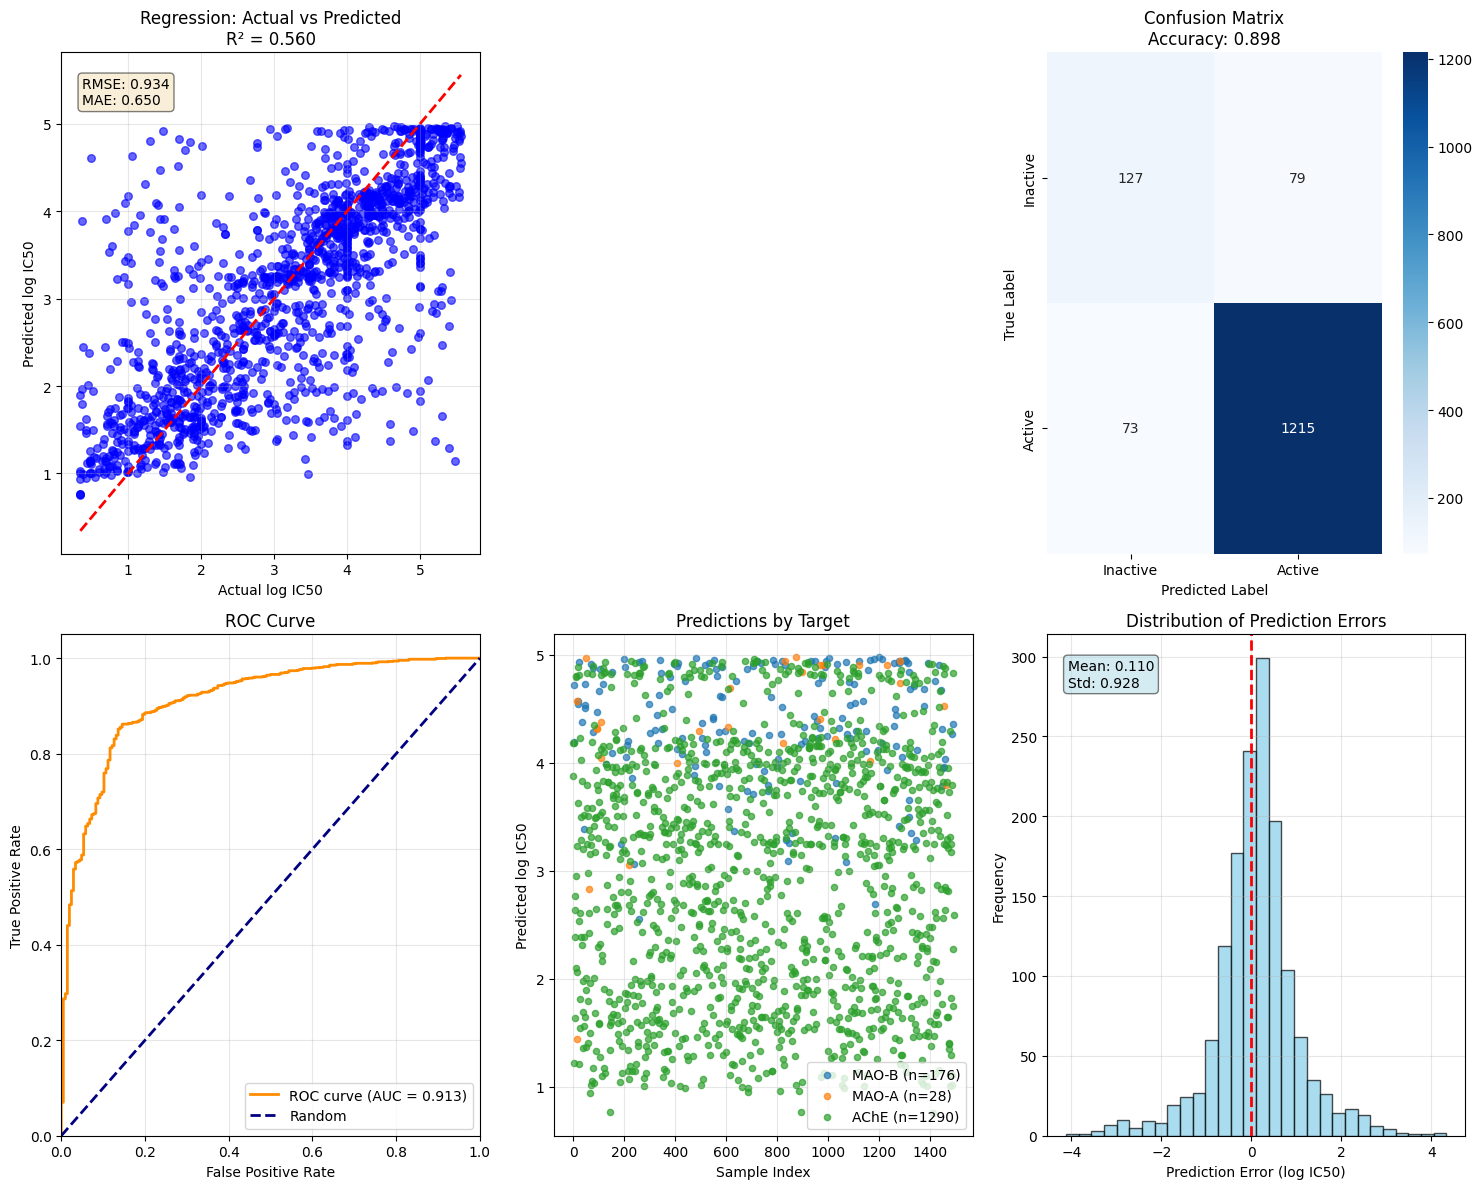

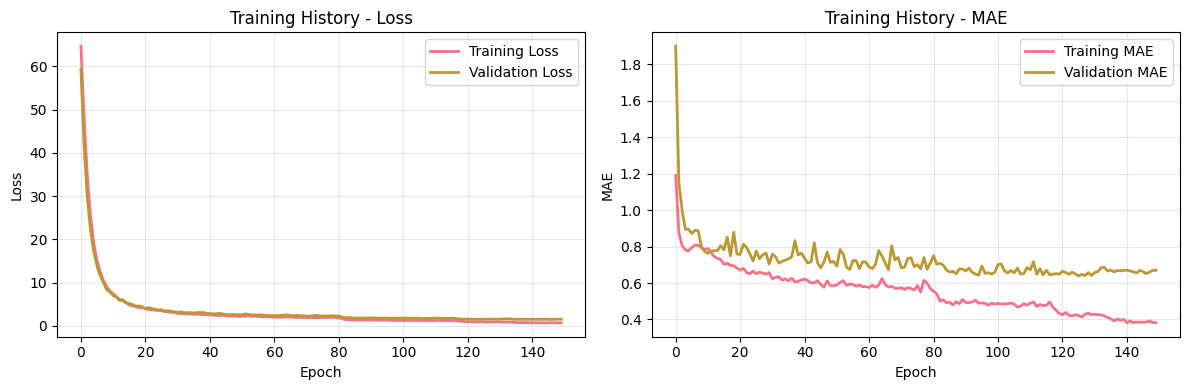

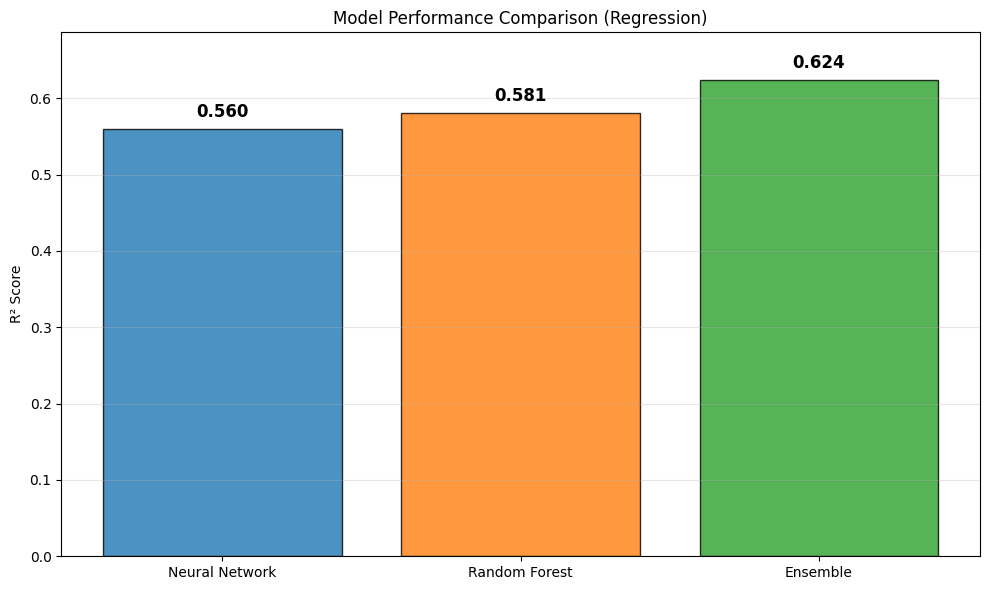

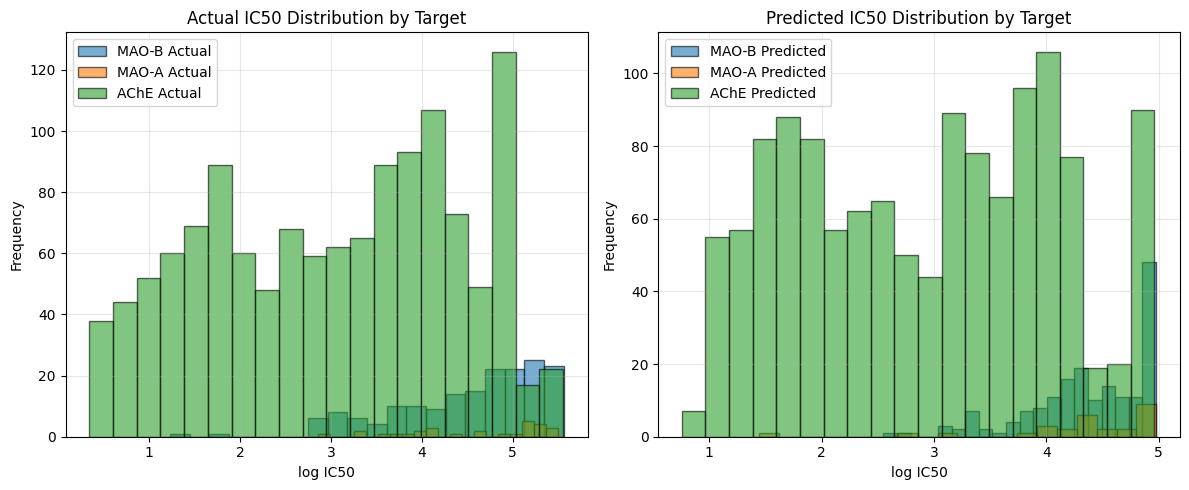


DETAILED PERFORMANCE SUMMARY
Metric               Value     
-----------------------------------
R² Score             0.5601
RMSE                 0.9342
MAE                  0.6500
Classification Acc   0.8983
ROC AUC              0.9130

All visualizations completed!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import pandas as pd

plt.style.use('default')
sns.set_palette("husl")


_, test_indices = train_test_split(
    range(len(df)), test_size=0.2, random_state=42, stratify=y_classification
)


original_test_targets = df.iloc[test_indices]['target'].values
target_names = ['MAO-B', 'MAO-A', 'AChE']
test_targets = [target_names[i] for i in original_test_targets]

print("TARGET DISTRIBUTION")
for i, target in enumerate(target_names):
    count = sum(1 for t in test_targets if t == target)
    print(f"{target}: {count} samples")

fig = plt.figure(figsize=(15, 12))

# 1. Regression: Actual vs Predicted
plt.subplot(2, 3, 1)
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6, s=30, c='blue')
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel('Actual log IC50')
plt.ylabel('Predicted log IC50')
plt.title(f'Regression: Actual vs Predicted\nR² = {r2:.3f}')
plt.grid(True, alpha=0.3)

plt.text(0.05, 0.95, f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


# 3. Confusion Matrix
plt.subplot(2, 3, 3)
cm = confusion_matrix(y_cls_test, y_cls_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.3f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 4. ROC Curve
plt.subplot(2, 3, 4)
y_cls_prob = predictions[1].flatten()
fpr, tpr, _ = roc_curve(y_cls_test, y_cls_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 5. Predictions by Target
plt.subplot(2, 3, 5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, target in enumerate(target_names):
    mask = np.array(test_targets) == target
    if np.sum(mask) > 0:
        plt.scatter(np.where(mask)[0], y_reg_pred[mask],
                   label=f'{target} (n={np.sum(mask)})', alpha=0.7, s=20, c=colors[i])

plt.xlabel('Sample Index')
plt.ylabel('Predicted log IC50')
plt.title('Predictions by Target')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Distribution of Prediction Errors
plt.subplot(2, 3, 6)
plt.hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prediction Error (log IC50)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True, alpha=0.3)

plt.text(0.05, 0.95, f'Mean: {np.mean(residuals):.3f}\nStd: {np.std(residuals):.3f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()


# Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History - Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['regression_mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_regression_mae'], label='Validation MAE', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training History - MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model Performance Comparison
plt.figure(figsize=(10, 6))
models = ['Neural Network', 'Random Forest', 'Ensemble']
r2_scores = [r2, rf_r2, ensemble_r2]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = plt.bar(models, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
plt.ylabel('R² Score')
plt.title('Model Performance Comparison (Regression)')
plt.ylim(0, max(r2_scores) * 1.1)

for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# IC50 Distribution by Target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, target in enumerate(target_names):
    mask = np.array(test_targets) == target
    if np.sum(mask) > 0:
        plt.hist(y_reg_test[mask], bins=20, alpha=0.6, label=f'{target} Actual',
                color=colors[i], edgecolor='black')

plt.xlabel('log IC50')
plt.ylabel('Frequency')
plt.title('Actual IC50 Distribution by Target')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, target in enumerate(target_names):
    mask = np.array(test_targets) == target
    if np.sum(mask) > 0:
        plt.hist(y_reg_pred[mask], bins=20, alpha=0.6, label=f'{target} Predicted',
                color=colors[i], edgecolor='black')

plt.xlabel('log IC50')
plt.ylabel('Frequency')
plt.title('Predicted IC50 Distribution by Target')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance Summary by Target
print("\nDETAILED PERFORMANCE SUMMARY")
print(f"{'Metric':<20} {'Value':<10}")
print("-" * 35)
print(f"{'R² Score':<20} {r2:.4f}")
print(f"{'RMSE':<20} {rmse:.4f}")
print(f"{'MAE':<20} {mae:.4f}")
print(f"{'Classification Acc':<20} {accuracy:.4f}")
print(f"{'ROC AUC':<20} {roc_auc:.4f}")


'''
print(f"\n{'Target':<10} {'Count':<8} {'Mean Error':<12} {'Std Error':<12}")
print("-" * 45)
for i, target in enumerate(target_names):
    mask = np.array(test_targets) == target
    if np.sum(mask) > 0:
        target_residuals = residuals[mask]
        print(f"{target:<10} {np.sum(mask):<8} {np.mean(target_residuals):<12.4f} {np.std(target_residuals):<12.4f}")
'''


print("\nAll visualizations completed!")